# Analysis of reciprocal connections overexpression

In [1]:
import conntility
import connalysis
import numpy
import pandas
from pathlib import Path

from scipy.spatial import distance

from matplotlib import pyplot as plt

In [2]:
root = "/Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix"
#root = Path("/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper")
# root = Path("/Users/mwr/Documents/artefacts/connectomes")

# Load the data

# Human model
#dataset_human == "human_model":
fn_human = root + "/Human_NEWfunct_conmat_filtered_compressed.h5"
M_human = conntility.ConnectivityMatrix.from_h5(fn_human)

# Human H01
#dataset_H01 == "human_em":
fn_H01 = root + "/Shapson_Coe_et_al_human_all_somas.h5"
M_H01 = conntility.ConnectivityMatrix.from_h5(fn_H01, "compressed")

# Microns
#dataset_microns == "mouse_em":
fn_microns = root + "/microns_mm3_connectome_v1181.h5"
M_microns = conntility.ConnectivityMatrix.from_h5(fn_microns, "condensed")

# Rat model
#dataset == "rat_model":
fn_rat = root + "/Rat_623um_squared_funct_conmat_filtered_compressed.h5"
M_rat = conntility.ConnectivityMatrix.from_h5(fn_rat)


#### Some useful functions

In [3]:
def bootstrapping_overexpression(nrec, ncon, npairs):
    nrec = numpy.array(nrec)
    ncon = numpy.array(ncon)
    npairs = numpy.array(npairs)

    rnd = numpy.random.choice(len(nrec), 200 * 1000).reshape((200, 1000))

    pcon = ncon[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)
    prec = nrec[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)

    #print('prec', prec.mean())

    over = prec / (pcon ** 2)
    #return prec.mean(), prec.std(), over.mean(), over.std()
    return over.mean(), over.std()

In [9]:
def patch_clamp_sampling_scales(scales, M):
    res = []
    prec = []
    for scale in scales:
        print(scale)
        mv_cv = numpy.array([[scale, 0.0],
                            [0.0, scale]]) ** 2

        npairs = []
        ncon = []
        nrec = []
        npatch = 12

        for _ in range(2000):
            mv_mn = numpy.random.rand(2) * 300 - 150
            try:
                smpl = M.patch_sample(npatch, mv_mn, mv_cv, columns_xy=xy_slice)
                npairs.append(len(smpl) * (len(smpl) - 1))
                ncon.append(len(smpl.edges))
                nrec.append(len(smpl.to_reciprocal().edges))
            except:
                pass
        prec_m, prec_std, over_m, over_std = bootstrapping_overexpression(nrec, ncon, npairs)
        #res.append(bootstrapping_overexpression(nrec, ncon, npairs))
        res.append((over_m, over_std))
        prec.append((prec_m, prec_std))
    res = numpy.vstack(res)
    prec = numpy.vstack(prec)

    return res, prec

In [5]:
# Compared to ER
def ER_comparison(M):
    ttl_npairs = len(M) * (len(M) - 1)
    ttl_ncon = len(M.edges)
    ttl_nrec = len(M.to_reciprocal().edges)

    ttl_pcon = ttl_ncon / ttl_npairs
    ttl_prec = ttl_nrec / ttl_npairs

    ttl_er_over = ttl_prec / (ttl_pcon ** 2)

    return ttl_er_over, ttl_nrec

In [6]:
# Compared to DD
def DD_comparison(M, ttl_nrec):
    mdl = connalysis.modelling.conn_prob_2nd_order_model(M.matrix.tocsc().astype(bool), M.vertices, coord_names=xy_slice)

    Ctrl = connalysis.randomization.run_DD2_model(M.matrix, M.vertices, model_params_dd2=mdl, coord_names=xy_slice)
    Ctrl = conntility.ConnectivityMatrix(Ctrl, vertex_properties=M._vertex_properties)
    Ctrl_r = Ctrl.to_reciprocal()   

    ttl_dd_over = ttl_nrec / len(Ctrl_r.edges)

    return ttl_dd_over

### Compute: HUMAN vs RAT models

Dataset-dependent pre-processing.

This turns the respective networks into virtual slices that we can experiment on.

In [7]:
# dataset == "human_model":
# HUMAN MODEL
# STEP 1: Only layers 2/3.
types_of_interest = [
    "L2_PTPC",
    "L3_PTPC",
    "L3_STPC",
    "L3_PC"
]
M_human = M_human.index("mtype").isin(types_of_interest)
# STEP 2:Create slice
M_human = M_human.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
xyz = ["x", "y", "z"]
xy_slice = ["slice_x", "slice_y"]

In [10]:
scales =[40, 80, 120, 160, 200, 240, 280, 320, 360, 400]
res_human, prec_human = patch_clamp_sampling_scales(scales, M_human)

40
80
120
160
200
240
280
320
360
400


In [12]:
ttl_er_over_human, ttl_nrec_human = ER_comparison(M_human)
ttl_dd_over_human = DD_comparison(M_human, ttl_nrec_human)

 2025-06-10 10:22:35,978: Running order-2 model building {'coord_names': ['slice_x', 'slice_y'], 'model_dir': None, 'data_dir': None, 'plot_dir': None, 'do_plot': False, 'part_idx': None, 'sample_seed': None}...
 2025-06-10 10:22:36,003: Extracting 1-dimensional (15) connection probabilities...
100% |#############################################################################################################################|
 2025-06-10 10:22:36,619: MODEL FIT: f(x) = 0.272850 * exp(-0.006380 * x)
 2025-06-10 10:22:36,621: Run DD2 model with parameters: 
      exp_model_scale  exp_model_exponent
seed                                     
None          0.27285             0.00638


In [13]:
#dataset == "rat_model":
# RAT MODEL
# STEP 1: Only EXC and only layers 2/3.
M_rat = M_rat.index("synapse_class").eq("EXC")
M_rat = M_rat.index("layer").isin(["2", "3"])
# STEP 2:Create slice
M_rat = M_rat.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
xyz = ["x", "y", "z"]
xy_slice = ["slice_x", "slice_y"]

In [14]:
res_rat, prec_rat = patch_clamp_sampling_scales(scales, M_rat)

40
80
120
160
200
240
280
320
360
400


In [15]:
ttl_er_over_rat, ttl_nrec_rat = ER_comparison(M_rat)
ttl_dd_over_rat = DD_comparison(M_rat, ttl_nrec_rat)

 2025-06-10 10:30:43,184: Running order-2 model building {'coord_names': ['slice_x', 'slice_y'], 'model_dir': None, 'data_dir': None, 'plot_dir': None, 'do_plot': False, 'part_idx': None, 'sample_seed': None}...
 2025-06-10 10:30:43,244: Extracting 1-dimensional (10) connection probabilities...
100% |#############################################################################################################################|
 2025-06-10 10:30:44,622: MODEL FIT: f(x) = 0.121115 * exp(-0.008440 * x)
 2025-06-10 10:30:44,623: Run DD2 model with parameters: 
      exp_model_scale  exp_model_exponent
seed                                     
None         0.121115             0.00844


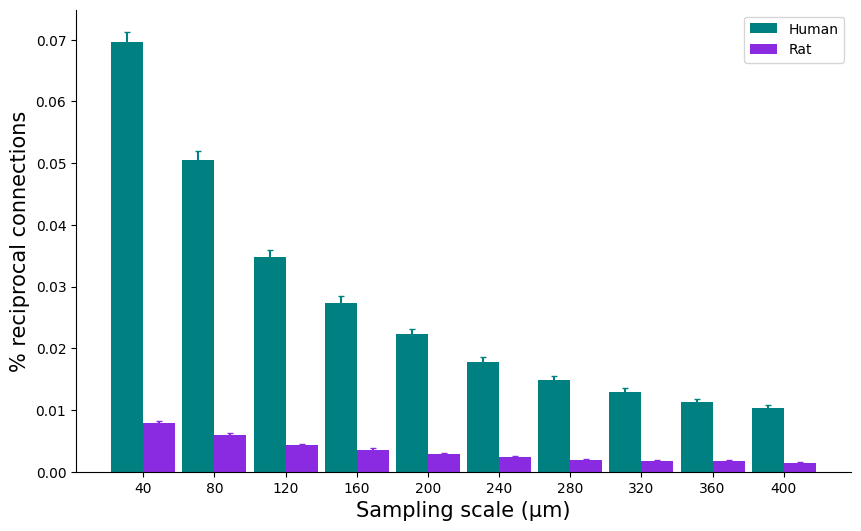

In [18]:
# Human vs Rat: % of recurrent connections (for supplementary figure)
fig = plt.figure(figsize=(10, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
ax = fig.gca()

barwidth = 18
#X = all_P_human.index.to_frame()["scale"].values  # same for both species
x_h = [x - barwidth/2 for x in scales]
x_r = [x + barwidth/2 for x in scales]

ax.bar(x_h, prec_human[:, 0], yerr=prec_human[:, 1], capsize=2, ecolor="teal", color="teal")
ax.bar(x_h, prec_human[:, 0], width=18, color="teal", label='Human')

ax.bar(x_r, prec_rat[:, 0], yerr=prec_rat[:, 1], capsize=2, ecolor="blueviolet", color="blueviolet")
ax.bar(x_r, prec_rat[:, 0], width=18, color="blueviolet", label='Rat')

ax.set_xlim(ax.get_xlim())
ticks = scales
ax.set_xticks(list(ticks))
ax.set_xlabel("Sampling scale (µm)", fontsize=15)
ax.set_ylabel("% reciprocal connections", fontsize=15)
ax.legend()
#plt.savefig('Precentage_Reciprocal_connect_samp_sizes.svg',transparent=True, bbox_inches='tight')

# Figure 4 Distance-dependence and sampling scale affect network complexity measurements.
#### B) Bar plot representing the over-expression of reciprocal connections at different sampling scales from (40 - 400) μm for the CPCs and two random models of Erd¨os-R´enyi (ER) and distance-dependent (DD), for human (teal) and rat (purple). Dashed gray line and gray arrow represents the value of reciprocal over-expression and the sampling scale for Peng et al., 2024 respectively. 

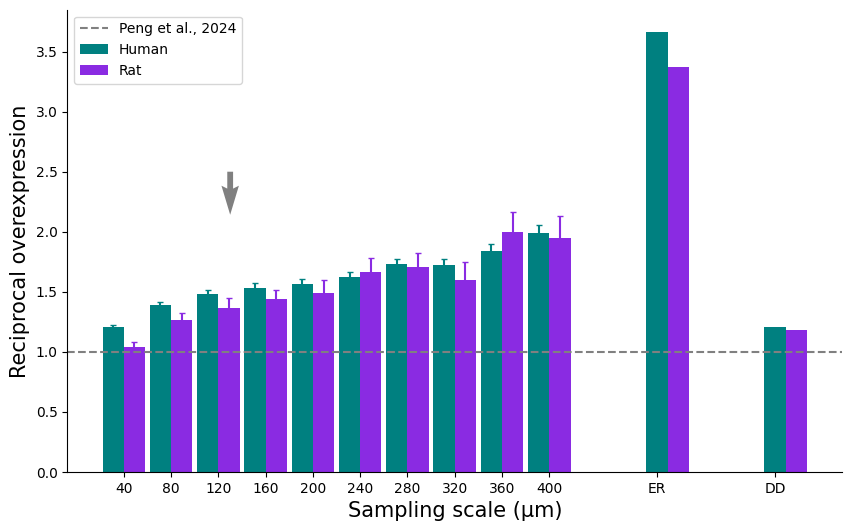

In [13]:
# Human vs Rat
fig = plt.figure(figsize=(10, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
ax = fig.gca()

#bar_loc_er_ctrl = scales[-1] + 100
#bar_loc_dd_ctrl = scales[-1] + 200

barwidth = 18
#X = all_P_human.index.to_frame()["scale"].values  # same for both species
x_h = [x - barwidth/2 for x in scales]
x_r = [x + barwidth/2 for x in scales]
x_extra_er_h = 500 - barwidth/2 #(scales[-1] + 100 * numpy.mean(numpy.diff(scales))) - barwidth/2
x_extra_dd_h = 600 - barwidth/2 #(scales[-1] + 200 * numpy.mean(numpy.diff(scales))) - barwidth/2
x_extra_er_r = 500 + barwidth/2 #(scales[-1] + 100 * numpy.mean(numpy.diff(scales))) + barwidth/2
x_extra_dd_r = 600 + barwidth/2 #(scales[-1] + 200 * numpy.mean(numpy.diff(scales))) + barwidth/2

ax.bar(x_h, res_human[:, 0], yerr=res_human[:, 1], capsize=2, ecolor="teal", color="teal")
ax.bar(x_h, res_human[:, 0], width=18, color="teal", label='Human')
ax.bar([x_extra_er_h], [ttl_er_over_human], width=18, color="teal")
ax.bar([x_extra_dd_h], [ttl_dd_over_human], width=18, color="teal")

ax.bar(x_r, res_rat[:, 0], yerr=res_rat[:, 1], capsize=2, ecolor="blueviolet", color="blueviolet")
ax.bar(x_r, res_rat[:, 0], width=18, color="blueviolet", label='Rat')
ax.bar([x_extra_er_r], [ttl_er_over_rat], width=18, color="blueviolet")
ax.bar([x_extra_dd_r], [ttl_dd_over_rat], width=18, color="blueviolet")

ax.set_xlim(ax.get_xlim())
ax.plot(ax.get_xlim(), [1, 1], color="grey", ls="--", label='Peng et al., 2024')
ax.quiver([130], [2.5], [0], [-2], color="grey")
ticks = scales
ax.set_xticks(list(ticks) + [x_extra_er_h, x_extra_dd_h])
ax.set_xticklabels(list(ticks) + ["ER", "DD"])
ax.set_xlabel("Sampling scale (µm)", fontsize=15)
ax.set_ylabel("Reciprocal overexpression", fontsize=15)
ax.legend()
plt.savefig('Reciprocal_count_Diff_samp_sizes.svg',transparent=True, bbox_inches='tight')

## Same analysis for H01 dataset (Figure S5)

In [15]:
#dataset == "human_em":
# Shapson-Coe

# STEP 1: Only neurons. Filter out non-neurons
types_of_interest = [
    "PYRAMIDAL",
    "INTERNEURON",
    "SPINY_ATYPICAL",
    "UNCLASSIFIED_NEURON",
    "SPINY_STELLATE"
]

M_H01 = M_H01.index("celltype").isin(types_of_interest)

# STEP 2: Convert from voxel indices to coordinates in um
xyz = ["x", "y", "z"]
full_res = numpy.array([ 8, 8, 33 ]) # voxel resultion in nm

for _col, _fac in zip(xyz, full_res):
    M_H01.add_vertex_property(_col + "_um", M_H01.vertices[_col].values * _fac / 1000)
xyz = ["x_um", "y_um", "z_um"]

# STEP 4: Only layer 2/3
M_H01 = M_H01.index("layer").isin(["Layer 2", "Layer 3"])

# Dataset already is a slice. With x and y as main coordinates and z the 200 um slice thickness
xy_slice = ["x_um", "y_um"]

In [20]:
res_H01 = patch_clamp_sampling_scales(scales, M_H01)

40
80
120
160
200
240
280
320
360
400


In [21]:
ttl_er_over_H01, ttl_nrec_H01 = ER_comparison(M_H01)
ttl_dd_over_H01 = DD_comparison(M_H01, ttl_nrec_H01)

 2025-06-06 17:00:57,913: Running order-2 model building {'coord_names': ['x_um', 'y_um'], 'model_dir': None, 'data_dir': None, 'plot_dir': None, 'do_plot': False, 'part_idx': None, 'sample_seed': None}...
 2025-06-06 17:00:58,044: Extracting 1-dimensional (23) connection probabilities...
100% |#############################################################################################################################|
 2025-06-06 17:01:02,387: MODEL FIT: f(x) = 0.025144 * exp(-0.012019 * x)
 2025-06-06 17:01:02,388: Run DD2 model with parameters: 
      exp_model_scale  exp_model_exponent
seed                                     
None         0.025144            0.012019


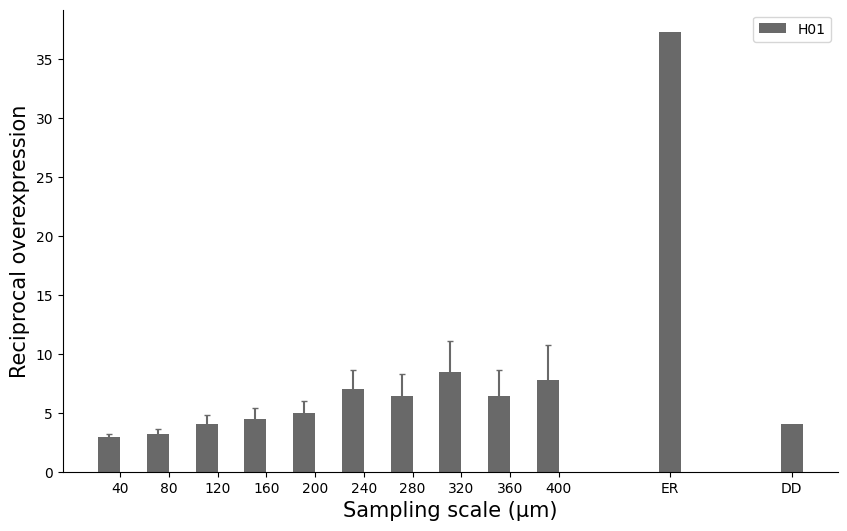

In [22]:
# H01
fig = plt.figure(figsize=(10, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
ax = fig.gca()

barwidth = 18
#X = all_P_human.index.to_frame()["scale"].values  # same for both species
x_h01 = [x - barwidth/2 for x in scales]

x_extra_er_h01 = 500 - barwidth/2 #(scales[-1] + 100 * numpy.mean(numpy.diff(scales))) - barwidth/2
x_extra_dd_h01 = 600 - barwidth/2 #(scales[-1] + 200 * numpy.mean(numpy.diff(scales))) - barwidth/2

ax.bar(x_h, res_H01[:, 0], yerr=res_H01[:, 1], capsize=2, ecolor="dimgray", color="dimgray")
ax.bar(x_h, res_H01[:, 0], width=18, color="dimgray", label='H01')
ax.bar([x_extra_er_h01], [ttl_er_over_H01], width=18, color="dimgray")
ax.bar([x_extra_dd_h01], [ttl_dd_over_H01], width=18, color="dimgray")

ax.set_xlim(ax.get_xlim())
ticks = scales
ax.set_xticks(list(ticks) + [x_extra_er_h01, x_extra_dd_h01])
ax.set_xticklabels(list(ticks) + ["ER", "DD"])
ax.set_xlabel("Sampling scale (µm)", fontsize=15)
ax.set_ylabel("Reciprocal overexpression", fontsize=15)
ax.legend()
#plt.savefig('Reciprocal_count_Diff_samp_sizes_H01.svg',transparent=True, bbox_inches='tight')

## Same analysis for MICRONS dataset (Figure S5)

In [25]:
#if dataset == "mouse_em":
# MICRONS

# STEP 1: Only layers 2/3.
types_of_interest = ["L2a", "L2b", "L2c", "L3a", "L3b"]
M_microns = M_microns.index("cell_type").isin(types_of_interest)

# STEP 2: Convert coordinates from nm to um
for _coord in ["x", "y", "z"]:
    M_microns.add_vertex_property(_coord, M_microns.vertices[_coord + "_nm"].values / 1000)

# STEP 3:Create slice
# In Microns the y-axis is sufficently close to vertical.
M_microns = M_microns.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    
xy_slice = ["slice_x", "slice_y"]

In [26]:
res_microns = patch_clamp_sampling_scales(scales, M_microns)

40
80
120
160
200
240
280
320
360
400


In [27]:
ttl_er_over_microns, ttl_nrec_microns = ER_comparison(M_microns)
ttl_dd_over_microns = DD_comparison(M_microns, ttl_nrec_microns)

 2025-06-06 18:06:13,827: Running order-2 model building {'coord_names': ['slice_x', 'slice_y'], 'model_dir': None, 'data_dir': None, 'plot_dir': None, 'do_plot': False, 'part_idx': None, 'sample_seed': None}...
 2025-06-06 18:06:13,921: Extracting 1-dimensional (14) connection probabilities...
100% |#############################################################################################################################|
 2025-06-06 18:06:16,020: MODEL FIT: f(x) = 0.041546 * exp(-0.014510 * x)
 2025-06-06 18:06:16,022: Run DD2 model with parameters: 
      exp_model_scale  exp_model_exponent
seed                                     
None         0.041546             0.01451


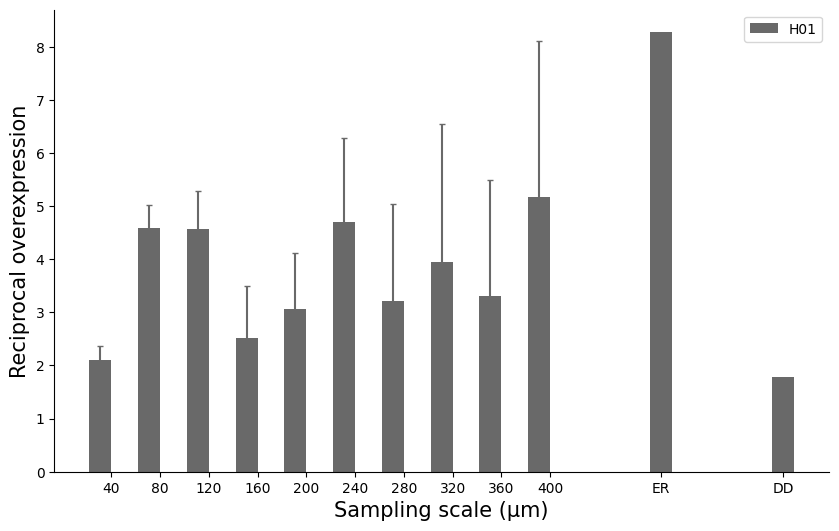

In [28]:
# MICRONS
fig = plt.figure(figsize=(10, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
ax = fig.gca()

barwidth = 18
#X = all_P_human.index.to_frame()["scale"].values  # same for both species
x_microns = [x - barwidth/2 for x in scales]

x_extra_er_microns = 500 - barwidth/2 #(scales[-1] + 100 * numpy.mean(numpy.diff(scales))) - barwidth/2
x_extra_dd_microns = 600 - barwidth/2 #(scales[-1] + 200 * numpy.mean(numpy.diff(scales))) - barwidth/2

ax.bar(x_microns, res_microns[:, 0], yerr=res_H01[:, 1], capsize=2, ecolor="dimgray", color="dimgray")
ax.bar(x_microns, res_microns[:, 0], width=18, color="dimgray", label='MICRONS')
ax.bar([x_extra_er_microns], [ttl_er_over_microns], width=18, color="dimgray")
ax.bar([x_extra_dd_microns], [ttl_dd_over_microns], width=18, color="dimgray")

ax.set_xlim(ax.get_xlim())
ticks = scales
ax.set_xticks(list(ticks) + [x_extra_er_h01, x_extra_dd_h01])
ax.set_xticklabels(list(ticks) + ["ER", "DD"])
ax.set_xlabel("Sampling scale (µm)", fontsize=15)
ax.set_ylabel("Reciprocal overexpression", fontsize=15)
ax.legend()
#plt.savefig('Reciprocal_count_Diff_samp_sizes_MICRONS.svg',transparent=True, bbox_inches='tight')